# Reanalyze the data based on cross-classified mixed-effects models

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

## 1. Data Preparation

In [2]:
df = pd.read_csv("evaluation_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (372, 24)


,participant_id,group,video_id,video_title,topic,video_order,attractive_plain,clear_confusing,organized_disorganized,comfortable_uncomfortable,...,factual_misleading,convincing_doubtful,pleasant_unpleasant,clear_unclear,smooth_abrupt,friendly_unfriendly,motivating_demotivating,stopping_or_skipping,first_bored_or_skip_point,overall_rating
0,P-20260711T030347Z-C30B56,B,S02,Video B07,Science,1,-1,-3,-3,-3,...,-3,-3,-3,-3,-3,-3,-3,slightly,early_middle,5
1,P-20260711T030347Z-C30B56,B,H04,Video B05,History,2,-3,-3,-3,-3,...,-1,-3,-3,-3,-3,-1,-2,slightly,late_middle,4
2,P-20260711T030347Z-C30B56,B,L03,Video B06,Language Learning,3,-1,-3,-3,-3,...,-3,-3,-3,-3,-3,-2,-3,not_at_all,not_bored_or_did_not_want_to_stop,4
3,P-20260711T030347Z-C30B56,B,S04,Video B10,Science,4,-1,-1,-2,-3,...,-3,-3,-1,1,-1,-3,1,quite_a_lot,early_middle,3
4,P-20260711T030347Z-C30B56,B,H01,Video B01,History,5,-3,-3,-3,-3,...,-1,-2,-1,1,-1,-2,-3,not_at_all,not_bored_or_did_not_want_to_stop,4


In [3]:
kansei_columns = [
    "attractive_plain",
    "clear_confusing",
    "organized_disorganized",
    "comfortable_uncomfortable",
    "coherent_scattered",
    "professional_amateur",
    "understandable_confusing",
    "interesting_boring",
    "factual_misleading",
    "convincing_doubtful",
    "pleasant_unpleasant",
    "clear_unclear",
    "smooth_abrupt",
    "friendly_unfriendly",
    "motivating_demotivating"
]

kansei_labels = {
    "attractive_plain": "Attractive–Plain",
    "clear_confusing": "Clear–Confusing",
    "organized_disorganized": "Organized–Disorganized",
    "comfortable_uncomfortable": "Comfortable–Uncomfortable",
    "coherent_scattered": "Coherent–Scattered",
    "professional_amateur": "Professional–Amateur",
    "understandable_confusing": "Understandable–Confusing",
    "interesting_boring": "Interesting–Boring",
    "factual_misleading": "Factual–Misleading",
    "convincing_doubtful": "Convincing–Doubtful",
    "pleasant_unpleasant": "Pleasant–Unpleasant",
    "clear_unclear": "Clear–Unclear",
    "smooth_abrupt": "Smooth–Abrupt",
    "friendly_unfriendly": "Friendly–Unfriendly",
    "motivating_demotivating": "Motivating–Demotivating"
}

print("Number of Kansei adjective pairs:", len(kansei_columns))

Number of Kansei adjective pairs: 15


In [4]:
required_columns = [
    "participant_id",
    "group",
    "video_id",
    "video_title",
    "topic",
    "video_order",
    "overall_rating"
] + kansei_columns

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:")
    for column in missing_columns:
        print("-", column)
else:
    print("All required columns are available.")


# Convert rating variables to numeric
for column in kansei_columns + ["overall_rating"]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

All required columns are available.


In [5]:
# Reverse scores so that higher values always represent
# the positive adjective in each pair.
#
# After reversal:
# +3 = strongly positive
#  0 = neutral
# -3 = strongly negative

df[kansei_columns] = -df[kansei_columns]

# Check score ranges
score_range = pd.DataFrame({
    "Minimum": df[kansei_columns].min(),
    "Maximum": df[kansei_columns].max(),
    "Mean": df[kansei_columns].mean()
})

display(score_range.round(3))

,Minimum,Maximum,Mean
attractive_plain,-3,3,0.723
clear_confusing,-3,3,1.140
organized_disorganized,-3,3,1.151
comfortable_uncomfortable,-3,3,0.927
coherent_scattered,-3,3,1.237
professional_amateur,-3,3,0.847
understandable_confusing,-3,3,1.312
interesting_boring,-3,3,0.653
factual_misleading,-3,3,1.239
convincing_doubtful,-3,3,1.038


In [6]:
# Standardize topic names
topic_mapping = {
    "Language Learning": "Language",
    "Science": "Science",
    "History": "History"
}

df["Topic"] = df["topic"].map(topic_mapping)

print(df["Topic"].value_counts(dropna=False))

Topic
Science     124
History     124
Language    124
Name: count, dtype: int64


In [7]:
# Create a unique identifier for each video
# because the same video_id labels occur in Sets A and B.

video_lookup = (
    df[
        [
            "group",
            "video_id",
            "video_title",
            "Topic"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["group", "video_id"]
    )
    .reset_index(drop=True)
)

video_lookup["Video_ID"] = [
    f"V{i+1:02d}"
    for i in range(len(video_lookup))
]

display(video_lookup)

,group,video_id,video_title,Topic,Video_ID
0,A,H01,Video A01,History,V01
1,A,H02,Video A02,History,V02
2,A,H03,Video A03,History,V03
3,A,H04,Video A05,History,V04
4,A,L01,Video A09,Language,V05
5,A,L02,Video A06,Language,V06
6,A,L03,Video A06,Language,V07
7,A,L04,Video A06,Language,V08
8,A,S01,Video A04,Science,V09
9,A,S02,Video A07,Science,V10


In [8]:
df = df.merge(
    video_lookup[
        [
            "group",
            "video_id",
            "Video_ID"
        ]
    ],
    on=["group", "video_id"],
    how="left"
)

print(
    "Number of unique videos:",
    df["Video_ID"].nunique()
)

Number of unique videos: 24


In [9]:
df["Video_Set"] = df["group"]

print(df["Video_Set"].value_counts())

Video_Set
B    192
A    180
Name: count, dtype: int64


In [10]:
n_observations = len(df)
n_participants = df["participant_id"].nunique()
n_videos = df["Video_ID"].nunique()

print("Number of observations:", n_observations)
print("Number of participants:", n_participants)
print("Number of videos:", n_videos)

Number of observations: 372
Number of participants: 31
Number of videos: 24


In [11]:
ratings_per_participant = (
    df.groupby("participant_id")
    .size()
)

print("\nRatings per participant:")
display(
    ratings_per_participant
    .describe()
    .to_frame("Number of Ratings")
)


Ratings per participant:


,Number of Ratings
count,31.0
mean,12.0
std,0.0
min,12.0
25%,12.0
50%,12.0
75%,12.0
max,12.0


In [12]:
ratings_per_video = (
    df.groupby("Video_ID")
    .size()
)

print("\nRatings per video:")
display(
    ratings_per_video
    .describe()
    .to_frame("Number of Ratings")
)


Ratings per video:


,Number of Ratings
count,24.000000
mean,15.500000
std,0.510754
min,15.000000
25%,15.000000
50%,15.500000
75%,16.000000
max,16.000000


In [13]:
analysis_columns = (
    [
        "participant_id",
        "Video_ID",
        "Video_Set",
        "Topic",
        "overall_rating"
    ]
    + kansei_columns
)

missing_summary = (
    df[analysis_columns]
    .isna()
    .sum()
    .to_frame("Missing")
)

missing_summary["Percent"] = (
    missing_summary["Missing"] /
    len(df) *
    100
)

display(missing_summary.round(2))

,Missing,Percent
participant_id,0,0.0
Video_ID,0,0.0
Video_Set,0,0.0
Topic,0,0.0
overall_rating,0,0.0
attractive_plain,0,0.0
clear_confusing,0,0.0
organized_disorganized,0,0.0
comfortable_uncomfortable,0,0.0
coherent_scattered,0,0.0


In [14]:
print("Overall Evaluation summary:")

display(
    df["overall_rating"]
    .describe()
    .to_frame("Overall Evaluation")
    .round(3)
)

print(
    "Missing overall ratings:",
    df["overall_rating"].isna().sum()
)

Overall Evaluation summary:


,Overall Evaluation
count,372.000
mean,3.306
std,1.203
min,1.000
25%,3.000
50%,3.000
75%,4.000
max,5.000


Missing overall ratings: 0


In [15]:
analysis_variables = (
    [
        "participant_id",
        "Video_ID",
        "Video_Set",
        "Topic",
        "video_order"
    ]
    + kansei_columns
    + ["overall_rating"]
)

analysis_df = df[analysis_variables].copy()

print("Final analysis dataset shape:", analysis_df.shape)

display(analysis_df.head(10))

Final analysis dataset shape: (372, 21)


,participant_id,Video_ID,Video_Set,Topic,video_order,attractive_plain,clear_confusing,organized_disorganized,comfortable_uncomfortable,coherent_scattered,...,understandable_confusing,interesting_boring,factual_misleading,convincing_doubtful,pleasant_unpleasant,clear_unclear,smooth_abrupt,friendly_unfriendly,motivating_demotivating,overall_rating
0,P-20260711T030347Z-C30B56,V22,B,Science,1,1,3,3,3,3,...,3,3,3,3,3,3,3,3,3,5
1,P-20260711T030347Z-C30B56,V16,B,History,2,3,3,3,3,3,...,3,1,1,3,3,3,3,1,2,4
2,P-20260711T030347Z-C30B56,V19,B,Language,3,1,3,3,3,3,...,3,1,3,3,3,3,3,2,3,4
3,P-20260711T030347Z-C30B56,V24,B,Science,4,1,1,2,3,1,...,-2,-2,3,3,1,-1,1,3,-1,3
4,P-20260711T030347Z-C30B56,V13,B,History,5,3,3,3,3,3,...,3,3,1,2,1,-1,1,2,3,4
5,P-20260711T030347Z-C30B56,V15,B,History,6,-2,-2,-2,-1,-2,...,-2,-2,-2,-3,-2,2,1,-1,-2,2
6,P-20260711T030347Z-C30B56,V17,B,Language,7,3,3,3,3,3,...,3,3,1,3,3,3,3,3,3,3
7,P-20260711T030347Z-C30B56,V23,B,Science,8,3,3,3,3,3,...,3,3,1,3,3,3,2,3,3,5
8,P-20260711T030347Z-C30B56,V20,B,Language,9,3,3,3,3,-2,...,3,1,1,2,3,3,3,3,3,4
9,P-20260711T030347Z-C30B56,V21,B,Science,10,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,5


In [16]:
sample_summary = pd.DataFrame({
    "Measure": [
        "Participants",
        "Videos",
        "Observations",
        "Kansei adjective pairs",
        "Missing Kansei ratings",
        "Missing overall ratings"
    ],
    "Value": [
        analysis_df["participant_id"].nunique(),
        analysis_df["Video_ID"].nunique(),
        len(analysis_df),
        len(kansei_columns),
        analysis_df[kansei_columns].isna().sum().sum(),
        analysis_df["overall_rating"].isna().sum()
    ]
})

display(sample_summary)

,Measure,Value
0,Participants,31
1,Videos,24
2,Observations,372
3,Kansei adjective pairs,15
4,Missing Kansei ratings,0
5,Missing overall ratings,0


In [77]:
participant_df = pd.read_csv("participant_data.csv")

print("Participant data shape:", participant_df.shape)
print("\nColumn names:")

for i, col in enumerate(participant_df.columns):
    print(i, col)

display(participant_df.head())

Participant data shape: (42, 18)

Column names:
0 participant_id
1 group
2 age
3 gender
4 country_region
5 native_language
6 education_level
7 short_video_frequency
8 platforms
9 usual_session_length
10 usual_video_types
11 used_short_videos_for_learning
12 learning_short_video_frequency
13 educational_video_usefulness
14 topic_preference_1
15 topic_preference_2
16 topic_preference_3
17 english_comfort_level


,participant_id,group,age,gender,country_region,native_language,education_level,short_video_frequency,platforms,usual_session_length,usual_video_types,used_short_videos_for_learning,learning_short_video_frequency,educational_video_usefulness,topic_preference_1,topic_preference_2,topic_preference_3,english_comfort_level
0,P-20260711T030347Z-C30B56,B,23_27,female,china,mandarin_chinese,undergraduate_student,multiple_times_a_day,other,30_60_min,"entertainment, cooking, life_hacks, gaming",yes,sometimes,5.0,history,language_learning,science,very_comfortable
1,<<<<<<< HEAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P-20260716T122815Z-7638DE,B,18_22,female,japan,japanese,high_school,multiple_times_a_day,youtube_shorts,10_30_min,"entertainment, science, language_learning, coo...",yes,rarely,2.0,language_learning,science,history,not_comfortable_at_all
3,P-20260714T143638Z-2D1695,A,18_22,male,taiwan,mandarin_chinese,undergraduate_student,about_once_a_day,"youtube_shorts, instagram_reels",more_than_2_hours,gaming,yes,rarely,2.0,science,history,language_learning,not_comfortable_at_all
4,P-20260712T092333Z-618D74,A,23_27,male,taiwan,mandarin_chinese,graduate_master,multiple_times_a_day,"tiktok, instagram_reels, facebook_reels",more_than_2_hours,"educational, entertainment, science, language_...",yes,very_often,5.0,language_learning,history,science,very_comfortable


In [78]:
# Check topic preference variables

display(
    participant_df[
        [
            "participant_id",
            "topic_preference_1",
            "topic_preference_2",
            "topic_preference_3"
        ]
    ].head(20)
)

for col in [
    "topic_preference_1",
    "topic_preference_2",
    "topic_preference_3"
]:
    print("\n", col)
    print(participant_df[col].value_counts(dropna=False))

,participant_id,topic_preference_1,topic_preference_2,topic_preference_3
0,P-20260711T030347Z-C30B56,history,language_learning,science
1,<<<<<<< HEAD,NaN,NaN,NaN
2,P-20260716T122815Z-7638DE,language_learning,science,history
3,P-20260714T143638Z-2D1695,science,history,language_learning
4,P-20260712T092333Z-618D74,language_learning,history,science
5,P-20260709T074312Z-5E8136,science,history,language_learning
6,P-20260709T052634Z-F27519,history,science,language_learning
7,P-20260713T060416Z-43E4E9,language_learning,science,history
8,P-20260714T085151Z-3B02E3,history,science,language_learning
9,P-20260709T080130Z-F2AA8F,language_learning,history,science



 topic_preference_1
topic_preference_1
language_learning    18
science              15
history               6
NaN                   3
Name: count, dtype: int64

 topic_preference_2
topic_preference_2
history              18
science              14
language_learning     7
NaN                   3
Name: count, dtype: int64

 topic_preference_3
topic_preference_3
history              15
language_learning    14
science              10
NaN                   3
Name: count, dtype: int64


## 2. Reliability Analysis: Cronbach's α + McDonald's ω

In [17]:
kansei_dimensions = {
    "Visual": [
        "attractive_plain",
        "clear_confusing",
        "organized_disorganized",
        "comfortable_uncomfortable",
        "coherent_scattered"
    ],

    "Content": [
        "professional_amateur",
        "understandable_confusing",
        "interesting_boring",
        "factual_misleading",
        "convincing_doubtful"
    ],

    "Audio_Narrator": [
        "pleasant_unpleasant",
        "clear_unclear",
        "smooth_abrupt",
        "friendly_unfriendly",
        "motivating_demotivating"
    ]
}

for dimension, columns in kansei_dimensions.items():
    print(dimension, ":", len(columns), "items")

Visual : 5 items
Content : 5 items
Audio_Narrator : 5 items


### Cronbach’s α

In [18]:
def cronbach_alpha(data):
    """
    Calculate Cronbach's alpha.

    Rows:
        participant-video evaluations

    Columns:
        scale items
    """

    clean_data = data.dropna()

    k = clean_data.shape[1]

    if k < 2:
        return np.nan

    item_variances = clean_data.var(
        axis=0,
        ddof=1
    )

    total_score = clean_data.sum(axis=1)

    total_variance = total_score.var(
        ddof=1
    )

    if total_variance == 0:
        return np.nan

    alpha = (
        k / (k - 1)
    ) * (
        1 -
        item_variances.sum() / total_variance
    )

    return alpha

In [19]:
alpha_results = []

for dimension, columns in kansei_dimensions.items():

    alpha = cronbach_alpha(
        analysis_df[columns]
    )

    alpha_results.append({
        "Scale": dimension,
        "Number of Items": len(columns),
        "N": analysis_df[columns].dropna().shape[0],
        "Cronbach Alpha": alpha
    })

alpha_results = pd.DataFrame(
    alpha_results
)

display(
    alpha_results.round(3)
)

,Scale,Number of Items,N,Cronbach Alpha
0,Visual,5,372,0.929
1,Content,5,372,0.904
2,Audio_Narrator,5,372,0.940


In [20]:
overall_alpha = cronbach_alpha(
    analysis_df[kansei_columns]
)

print(
    "Cronbach's alpha for all 15 Kansei items:",
    round(overall_alpha, 3)
)

Cronbach's alpha for all 15 Kansei items: 0.968


#### Corrected item-total correlation + alpha if deleted

檢查有沒有哪一題拖累 reliability

In [21]:
def item_reliability_analysis(data):

    clean_data = data.dropna()

    results = []

    for column in clean_data.columns:

        other_columns = [
            c for c in clean_data.columns
            if c != column
        ]

        other_total = (
            clean_data[other_columns]
            .sum(axis=1)
        )

        corrected_item_total = (
            clean_data[column]
            .corr(other_total)
        )

        alpha_if_deleted = cronbach_alpha(
            clean_data[other_columns]
        )

        results.append({
            "Item": column,
            "Corrected Item-Total Correlation":
                corrected_item_total,
            "Cronbach Alpha if Deleted":
                alpha_if_deleted
        })

    return pd.DataFrame(results)

In [22]:
item_reliability_tables = {}

for dimension, columns in kansei_dimensions.items():

    print("\n" + "=" * 60)
    print(dimension)
    print("=" * 60)

    table = item_reliability_analysis(
        analysis_df[columns]
    )

    table["Item Label"] = (
        table["Item"]
        .map(kansei_labels)
    )

    table = table[
        [
            "Item",
            "Item Label",
            "Corrected Item-Total Correlation",
            "Cronbach Alpha if Deleted"
        ]
    ]

    item_reliability_tables[dimension] = table

    display(
        table.round(3)
    )


Visual


,Item,Item Label,Corrected Item-Total Correlation,Cronbach Alpha if Deleted
0,attractive_plain,Attractive–Plain,0.708,0.934
1,clear_confusing,Clear–Confusing,0.844,0.907
2,organized_disorganized,Organized–Disorganized,0.859,0.904
3,comfortable_uncomfortable,Comfortable–Uncomfortable,0.843,0.907
4,coherent_scattered,Coherent–Scattered,0.823,0.911



Content


,Item,Item Label,Corrected Item-Total Correlation,Cronbach Alpha if Deleted
0,professional_amateur,Professional–Amateur,0.777,0.879
1,understandable_confusing,Understandable–Confusing,0.782,0.878
2,interesting_boring,Interesting–Boring,0.626,0.918
3,factual_misleading,Factual–Misleading,0.822,0.873
4,convincing_doubtful,Convincing–Doubtful,0.838,0.866



Audio_Narrator


,Item,Item Label,Corrected Item-Total Correlation,Cronbach Alpha if Deleted
0,pleasant_unpleasant,Pleasant–Unpleasant,0.850,0.925
1,clear_unclear,Clear–Unclear,0.828,0.928
2,smooth_abrupt,Smooth–Abrupt,0.865,0.921
3,friendly_unfriendly,Friendly–Unfriendly,0.871,0.921
4,motivating_demotivating,Motivating–Demotivating,0.788,0.935


### McDonald’s ω

In [23]:
!pip install factor_analyzer


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [24]:
from factor_analyzer import FactorAnalyzer

In [25]:
def mcdonald_omega(data):
    """
    Calculate McDonald's omega total
    using a one-factor model.
    """

    clean_data = data.dropna()

    if clean_data.shape[1] < 2:
        return np.nan

    # Standardize items
    standardized = (
        clean_data - clean_data.mean()
    ) / clean_data.std(ddof=1)

    fa = FactorAnalyzer(
        n_factors=1,
        rotation=None,
        method="minres"
    )

    fa.fit(standardized)

    loadings = (
        fa.loadings_
        .flatten()
    )

    uniquenesses = fa.get_uniquenesses()

    numerator = (
        loadings.sum()
    ) ** 2

    denominator = (
        numerator
        +
        uniquenesses.sum()
    )

    omega = (
        numerator / denominator
    )

    return omega

#### Calculate ω for each dimension

In [26]:
omega_results = []

for dimension, columns in kansei_dimensions.items():

    omega = mcdonald_omega(
        analysis_df[columns]
    )

    omega_results.append({
        "Scale": dimension,
        "Number of Items": len(columns),
        "N": analysis_df[columns].dropna().shape[0],
        "McDonald's Omega": omega
    })

omega_results = pd.DataFrame(
    omega_results
)

display(
    omega_results.round(3)
)

,Scale,Number of Items,N,McDonald's Omega
0,Visual,5,372,0.932
1,Content,5,372,0.913
2,Audio_Narrator,5,372,0.941


#### Overall ω for all 15 items

In [27]:
overall_omega = mcdonald_omega(
    analysis_df[kansei_columns]
)

print(
    "McDonald's omega for all 15 Kansei items:",
    round(overall_omega, 3)
)

McDonald's omega for all 15 Kansei items: 0.969


### Combine α and ω into one final table

In [28]:
reliability_summary = (
    alpha_results
    .merge(
        omega_results,
        on=[
            "Scale",
            "Number of Items",
            "N"
        ]
    )
)

overall_row = pd.DataFrame({
    "Scale": ["All 15 Kansei Items"],
    "Number of Items": [15],
    "N": [
        analysis_df[
            kansei_columns
        ].dropna().shape[0]
    ],
    "Cronbach Alpha": [
        overall_alpha
    ],
    "McDonald's Omega": [
        overall_omega
    ]
})

reliability_summary = pd.concat(
    [
        reliability_summary,
        overall_row
    ],
    ignore_index=True
)

display(
    reliability_summary.round(3)
)

,Scale,Number of Items,N,Cronbach Alpha,McDonald's Omega
0,Visual,5,372,0.929,0.932
1,Content,5,372,0.904,0.913
2,Audio_Narrator,5,372,0.940,0.941
3,All 15 Kansei Items,15,372,0.968,0.969


## 3. Construct Validity：KMO + Bartlett + Parallel Analysis + EFA

In [29]:
from factor_analyzer import (
    FactorAnalyzer,
    calculate_kmo,
    calculate_bartlett_sphericity
)

from scipy.stats import zscore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
efa_data = (
    analysis_df[kansei_columns]
    .dropna()
    .copy()
)

print("EFA sample size:", len(efa_data))
print("Number of items:", efa_data.shape[1])

display(
    efa_data.describe().T.round(3)
)

EFA sample size: 372
Number of items: 15


,count,mean,std,min,25%,50%,75%,max
attractive_plain,372.0,0.723,1.744,-3.0,-1.0,1.0,2.0,3.0
clear_confusing,372.0,1.140,1.727,-3.0,0.0,2.0,2.0,3.0
organized_disorganized,372.0,1.151,1.585,-3.0,0.0,1.0,2.0,3.0
comfortable_uncomfortable,372.0,0.927,1.651,-3.0,0.0,1.0,2.0,3.0
coherent_scattered,372.0,1.237,1.538,-3.0,0.0,2.0,2.0,3.0
professional_amateur,372.0,0.847,1.616,-3.0,0.0,1.0,2.0,3.0
understandable_confusing,372.0,1.312,1.588,-3.0,1.0,2.0,3.0,3.0
interesting_boring,372.0,0.653,1.894,-3.0,-1.0,1.0,2.0,3.0
factual_misleading,372.0,1.239,1.442,-3.0,0.0,1.0,2.0,3.0
convincing_doubtful,372.0,1.038,1.598,-3.0,0.0,1.0,2.0,3.0


### KMO test

這些 variables 的 correlation structure 適不適合做 factor analysis。

In [31]:
kmo_per_item, kmo_total = calculate_kmo(
    efa_data
)

print(
    "Overall KMO:",
    round(kmo_total, 3)
)

Overall KMO: 0.956


In [32]:
kmo_table = pd.DataFrame({
    "Item": kansei_columns,
    "Item Label": [
        kansei_labels[col]
        for col in kansei_columns
    ],
    "KMO": kmo_per_item
})

display(
    kmo_table.round(3)
)

,Item,Item Label,KMO
0,attractive_plain,Attractive–Plain,0.956
1,clear_confusing,Clear–Confusing,0.960
2,organized_disorganized,Organized–Disorganized,0.968
3,comfortable_uncomfortable,Comfortable–Uncomfortable,0.951
4,coherent_scattered,Coherent–Scattered,0.955
5,professional_amateur,Professional–Amateur,0.975
6,understandable_confusing,Understandable–Confusing,0.962
7,interesting_boring,Interesting–Boring,0.962
8,factual_misleading,Factual–Misleading,0.920
9,convincing_doubtful,Convincing–Doubtful,0.937


### Bartlett’s Test of Sphericity
correlation matrix 是否接近 identity matrix。

In [33]:
bartlett_chi2, bartlett_p = (
    calculate_bartlett_sphericity(
        efa_data
    )
)

print(
    "Bartlett's chi-square:",
    round(bartlett_chi2, 3)
)

print(
    "Bartlett's p-value:",
    bartlett_p
)

Bartlett's chi-square: 6006.847
Bartlett's p-value: 0.0


### Initial eigenvalues

In [34]:
fa_initial = FactorAnalyzer(
    n_factors=len(kansei_columns),
    rotation=None,
    method="minres"
)

fa_initial.fit(efa_data)

eigenvalues, _ = (
    fa_initial.get_eigenvalues()
)

eigenvalue_table = pd.DataFrame({
    "Factor": np.arange(
        1,
        len(eigenvalues) + 1
    ),
    "Eigenvalue": eigenvalues
})

display(
    eigenvalue_table.round(3)
)

,Factor,Eigenvalue
0,1,10.487
1,2,0.945
2,3,0.726
3,4,0.501
4,5,0.368
5,6,0.319
6,7,0.259
7,8,0.244
8,9,0.230
9,10,0.201


### Scree plot

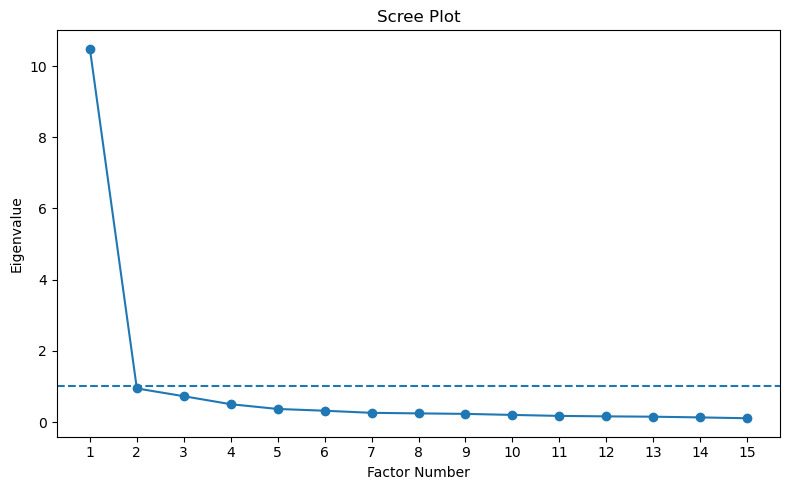

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--"
)

plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")

plt.xticks(
    range(1, len(eigenvalues) + 1)
)

plt.tight_layout()
plt.show()

### Parallel Analysis
把你的真實 eigenvalues 跟隨機資料的 eigenvalues 比較。

In [36]:
def parallel_analysis(
    data,
    n_iterations=1000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    n_rows, n_cols = data.shape

    # Correlation matrix of real data
    real_corr = np.corrcoef(
        data,
        rowvar=False
    )

    real_eigenvalues = np.linalg.eigvalsh(
        real_corr
    )[::-1]

    random_eigenvalues = np.zeros(
        (n_iterations, n_cols)
    )

    for i in range(n_iterations):

        random_data = rng.normal(
            size=(n_rows, n_cols)
        )

        random_corr = np.corrcoef(
            random_data,
            rowvar=False
        )

        random_eigenvalues[i] = (
            np.linalg.eigvalsh(
                random_corr
            )[::-1]
        )

    # 95th percentile of random eigenvalues
    random_95 = np.percentile(
        random_eigenvalues,
        95,
        axis=0
    )

    return (
        real_eigenvalues,
        random_95
    )

In [37]:
real_eigenvalues, random_eigenvalues_95 = (
    parallel_analysis(
        efa_data,
        n_iterations=1000
    )
)

In [38]:
parallel_table = pd.DataFrame({
    "Factor": np.arange(
        1,
        len(real_eigenvalues) + 1
    ),
    "Real Eigenvalue":
        real_eigenvalues,
    "Random 95th Percentile":
        random_eigenvalues_95
})

parallel_table[
    "Retain"
] = (
    parallel_table[
        "Real Eigenvalue"
    ]
    >
    parallel_table[
        "Random 95th Percentile"
    ]
)

display(
    parallel_table.round(3)
)

,Factor,Real Eigenvalue,Random 95th Percentile,Retain
0,1,10.487,1.428,True
1,2,0.945,1.333,False
2,3,0.726,1.262,False
3,4,0.501,1.205,False
4,5,0.368,1.152,False
5,6,0.319,1.105,False
6,7,0.259,1.063,False
7,8,0.244,1.023,False
8,9,0.230,0.981,False
9,10,0.201,0.945,False


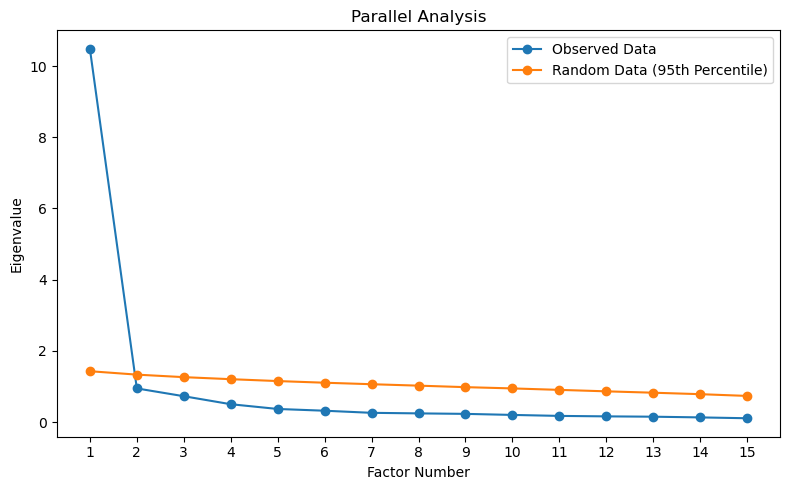

In [39]:
plt.figure(figsize=(8, 5))

factor_numbers = np.arange(
    1,
    len(real_eigenvalues) + 1
)

plt.plot(
    factor_numbers,
    real_eigenvalues,
    marker="o",
    label="Observed Data"
)

plt.plot(
    factor_numbers,
    random_eigenvalues_95,
    marker="o",
    label="Random Data (95th Percentile)"
)

plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")

plt.xticks(factor_numbers)

plt.legend()
plt.tight_layout()
plt.show()

### Automatically determine number of factors

In [40]:
n_factors = int(
    (
        real_eigenvalues
        >
        random_eigenvalues_95
    ).sum()
)

print(
    "Number of factors suggested by parallel analysis:",
    n_factors
)

Number of factors suggested by parallel analysis: 1


### EFA

In [41]:
efa_model = FactorAnalyzer(
    n_factors=n_factors,
    rotation="oblimin",
    method="minres"
)

efa_model.fit(
    efa_data
)

/opt/anaconda3/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


FactorAnalyzer(n_factors=1, rotation='oblimin', rotation_kwargs={})

In [42]:
factor_names = [
    f"Factor_{i+1}"
    for i in range(n_factors)
]

loading_table = pd.DataFrame(
    efa_model.loadings_,
    index=[
        kansei_labels[col]
        for col in kansei_columns
    ],
    columns=factor_names
)

display(
    loading_table.round(3)
)

,Factor_1
Attractive–Plain,0.754
Clear–Confusing,0.864
Organized–Disorganized,0.886
Comfortable–Uncomfortable,0.873
Coherent–Scattered,0.836
Professional–Amateur,0.792
Understandable–Confusing,0.816
Interesting–Boring,0.750
Factual–Misleading,0.761
Convincing–Doubtful,0.807


In [43]:
loading_summary = (
    loading_table
    .copy()
)

loading_summary[
    "Strongest Factor"
] = (
    loading_summary
    .abs()
    .idxmax(axis=1)
)

loading_summary[
    "Strongest Loading"
] = [
    loading_summary.loc[
        item,
        factor
    ]
    for item, factor in zip(
        loading_summary.index,
        loading_summary[
            "Strongest Factor"
        ]
    )
]

display(
    loading_summary.round(3)
)

,Factor_1,Strongest Factor,Strongest Loading
Attractive–Plain,0.754,Factor_1,0.754
Clear–Confusing,0.864,Factor_1,0.864
Organized–Disorganized,0.886,Factor_1,0.886
Comfortable–Uncomfortable,0.873,Factor_1,0.873
Coherent–Scattered,0.836,Factor_1,0.836
Professional–Amateur,0.792,Factor_1,0.792
Understandable–Confusing,0.816,Factor_1,0.816
Interesting–Boring,0.750,Factor_1,0.750
Factual–Misleading,0.761,Factor_1,0.761
Convincing–Doubtful,0.807,Factor_1,0.807


### Communalities
Communality 表示每個 item 有多少 variance 被 factor structure 解釋。

In [44]:
communalities = pd.DataFrame({
    "Item": [
        kansei_labels[col]
        for col in kansei_columns
    ],
    "Communality":
        efa_model.get_communalities()
})

display(
    communalities.round(3)
)

,Item,Communality
0,Attractive–Plain,0.569
1,Clear–Confusing,0.746
2,Organized–Disorganized,0.784
3,Comfortable–Uncomfortable,0.761
4,Coherent–Scattered,0.699
5,Professional–Amateur,0.627
6,Understandable–Confusing,0.667
7,Interesting–Boring,0.562
8,Factual–Misleading,0.579
9,Convincing–Doubtful,0.652


### Uniqueness

In [45]:
uniqueness = pd.DataFrame({
    "Item": [
        kansei_labels[col]
        for col in kansei_columns
    ],
    "Uniqueness":
        efa_model.get_uniquenesses()
})

display(
    uniqueness.round(3)
)

,Item,Uniqueness
0,Attractive–Plain,0.431
1,Clear–Confusing,0.254
2,Organized–Disorganized,0.216
3,Comfortable–Uncomfortable,0.239
4,Coherent–Scattered,0.301
5,Professional–Amateur,0.373
6,Understandable–Confusing,0.333
7,Interesting–Boring,0.438
8,Factual–Misleading,0.421
9,Convincing–Doubtful,0.348


### Variance explained

In [46]:
variance = (
    efa_model.get_factor_variance()
)

variance_table = pd.DataFrame({
    "Factor": factor_names,
    "SS Loadings": variance[0],
    "Proportion Variance":
        variance[1],
    "Cumulative Variance":
        variance[2]
})

display(
    variance_table.round(3)
)

,Factor,SS Loadings,Proportion Variance,Cumulative Variance
0,Factor_1,10.171,0.678,0.678


### Factor correlation matrix

In [47]:
if hasattr(efa_model, "phi_") and efa_model.phi_ is not None:

    factor_correlation = pd.DataFrame(
        efa_model.phi_,
        index=factor_names,
        columns=factor_names
    )

    print("Factor correlation matrix:")
    display(
        factor_correlation.round(3)
    )

### Meaningful loadings

In [48]:
loading_display = (
    loading_table.copy()
)

loading_display = (
    loading_display
    .applymap(
        lambda x:
        round(x, 3)
        if abs(x) >= 0.40
        else ""
    )
)

display(
    loading_display
)

/var/folders/81/lzptx5k11731vrk47tr0fc740000gn/T/ipykernel_31404/535518360.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(


,Factor_1
Attractive–Plain,0.754
Clear–Confusing,0.864
Organized–Disorganized,0.886
Comfortable–Uncomfortable,0.873
Coherent–Scattered,0.836
Professional–Amateur,0.792
Understandable–Confusing,0.816
Interesting–Boring,0.750
Factual–Misleading,0.761
Convincing–Doubtful,0.807


### Factor scores

In [49]:
factor_scores = (
    efa_model.transform(
        efa_data
    )
)

factor_score_df = pd.DataFrame(
    factor_scores,
    columns=factor_names,
    index=efa_data.index
)

display(
    factor_score_df.head()
)

,Factor_1
0,1.350493
1,1.063049
2,1.233896
3,0.146474
4,0.822641


In [50]:
analysis_df = (
    analysis_df
    .join(
        factor_score_df
    )
)

display(
    analysis_df[
        factor_names
    ].head()
)

,Factor_1
0,1.350493
1,1.063049
2,1.233896
3,0.146474
4,0.822641


In [51]:
display(
    analysis_df[
        factor_names
    ]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
Factor_1,372.0,0.0,0.987,-2.886,-0.643,0.118,0.721,1.412


In [52]:
analysis_df = analysis_df.rename(
    columns={
        "Factor_1": "General_Kansei_Evaluation"
    }
)

print(
    analysis_df[
        "General_Kansei_Evaluation"
    ].describe().round(3)
)

count    372.000
mean       0.000
std        0.987
min       -2.886
25%       -0.643
50%        0.118
75%        0.721
max        1.412
Name: General_Kansei_Evaluation, dtype: float64


## 4. Pearson Correlation：15 Kansei adjectives × Overall Evaluation

In [53]:
print("Overall Evaluation:")
display(
    analysis_df["overall_rating"]
    .describe()
    .to_frame("Overall Evaluation")
    .round(3)
)

print(
    "Missing Overall Evaluation:",
    analysis_df["overall_rating"].isna().sum()
)

print(
    "Missing Kansei ratings:",
    analysis_df[kansei_columns].isna().sum().sum()
)

Overall Evaluation:


,Overall Evaluation
count,372.000
mean,3.306
std,1.203
min,1.000
25%,3.000
50%,3.000
75%,4.000
max,5.000


Missing Overall Evaluation: 0
Missing Kansei ratings: 0


In [56]:
# 15 Kansei adjectives × Overall Evaluation

correlation_results = []

for column in kansei_columns:

    correlation_data = (
        analysis_df[
            [
                column,Multiple-comparison correction
                "overall_rating"
            ]
        ]
        .dropna()
    )

    r_value, p_value = stats.pearsonr(
        correlation_data[column],
        correlation_data["overall_rating"]
    )

    correlation_results.append({
        "Kansei Column": column,
        "Kansei Adjective": kansei_labels[column],
        "N": len(correlation_data),
        "Pearson r": r_value,
        "Raw p-value": p_value
    })


correlation_results = pd.DataFrame(
    correlation_results
)

display(
    correlation_results.round(4)
)

,Kansei Column,Kansei Adjective,N,Pearson r,Raw p-value
0,attractive_plain,Attractive–Plain,372,0.7483,0.0
1,clear_confusing,Clear–Confusing,372,0.7420,0.0
2,organized_disorganized,Organized–Disorganized,372,0.6996,0.0
3,comfortable_uncomfortable,Comfortable–Uncomfortable,372,0.7590,0.0
4,coherent_scattered,Coherent–Scattered,372,0.6673,0.0
5,professional_amateur,Professional–Amateur,372,0.6580,0.0
6,understandable_confusing,Understandable–Confusing,372,0.6326,0.0
7,interesting_boring,Interesting–Boring,372,0.7424,0.0
8,factual_misleading,Factual–Misleading,372,0.5976,0.0
9,convincing_doubtful,Convincing–Doubtful,372,0.6473,0.0


### Multiple-comparison correction

In [57]:
# Holm correction for 15 correlation tests

reject, adjusted_p, _, _ = multipletests(
    correlation_results["Raw p-value"],
    alpha=0.05,
    method="holm"
)

correlation_results[
    "Adjusted p-value"
] = adjusted_p

correlation_results[
    "Significant after Holm"
] = reject

In [58]:
correlation_results[
    "Absolute r"
] = (
    correlation_results[
        "Pearson r"
    ].abs()
)

correlation_results[
    "Rank"
] = (
    correlation_results[
        "Absolute r"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

In [59]:
def interpret_correlation(r):

    absolute_r = abs(r)

    if absolute_r < 0.10:
        return "Negligible"

    elif absolute_r < 0.30:
        return "Weak"

    elif absolute_r < 0.50:
        return "Moderate"

    elif absolute_r < 0.70:
        return "Strong"

    else:
        return "Very strong"


correlation_results[
    "Strength"
] = (
    correlation_results[
        "Pearson r"
    ]
    .apply(
        interpret_correlation
    )
)

In [60]:
correlation_results = (
    correlation_results
    .sort_values(
        "Absolute r",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    correlation_results[
        [
            "Rank",
            "Kansei Adjective",
            "N",
            "Pearson r",
            "Strength",
            "Raw p-value",
            "Adjusted p-value",
            "Significant after Holm"
        ]
    ].round(4)
)

,Rank,Kansei Adjective,N,Pearson r,Strength,Raw p-value,Adjusted p-value,Significant after Holm
0,1,Comfortable–Uncomfortable,372,0.7590,Very strong,0.0,0.0,True
1,2,Attractive–Plain,372,0.7483,Very strong,0.0,0.0,True
2,3,Motivating–Demotivating,372,0.7470,Very strong,0.0,0.0,True
3,4,Interesting–Boring,372,0.7424,Very strong,0.0,0.0,True
4,5,Clear–Confusing,372,0.7420,Very strong,0.0,0.0,True
5,6,Pleasant–Unpleasant,372,0.7218,Very strong,0.0,0.0,True
6,7,Friendly–Unfriendly,372,0.7002,Very strong,0.0,0.0,True
7,8,Organized–Disorganized,372,0.6996,Strong,0.0,0.0,True
8,9,Smooth–Abrupt,372,0.6848,Strong,0.0,0.0,True
9,10,Clear–Unclear,372,0.6840,Strong,0.0,0.0,True


### Correlation coefficient plot

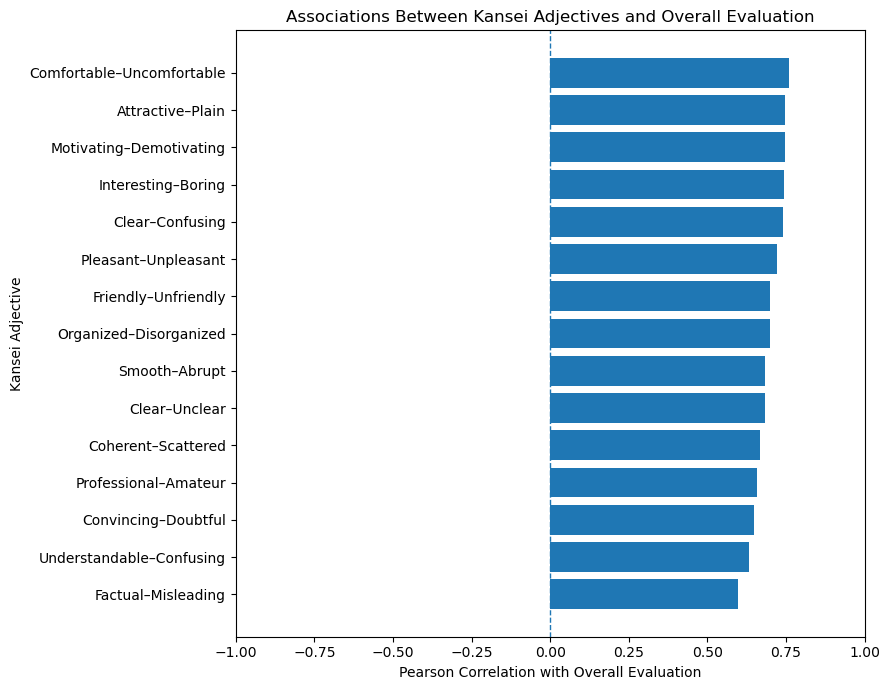

In [61]:
plot_data = (
    correlation_results
    .sort_values(
        "Pearson r",
        ascending=True
    )
)

plt.figure(
    figsize=(9, 7)
)

plt.barh(
    plot_data["Kansei Adjective"],
    plot_data["Pearson r"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Pearson Correlation with Overall Evaluation"
)

plt.ylabel(
    "Kansei Adjective"
)

plt.title(
    "Associations Between Kansei Adjectives "
    "and Overall Evaluation"
)

plt.xlim(
    -1,
    1
)

plt.tight_layout()
plt.show()

### General Kansei Evaluation × Overall Evaluation

In [62]:
general_data = (
    analysis_df[
        [
            "General_Kansei_Evaluation",
            "overall_rating"
        ]
    ]
    .dropna()
)

general_r, general_p = stats.pearsonr(
    general_data[
        "General_Kansei_Evaluation"
    ],
    general_data[
        "overall_rating"
    ]
)

print(
    "General Kansei Evaluation × Overall Evaluation"
)

print(
    "N =",
    len(general_data)
)

print(
    "Pearson r =",
    round(general_r, 3)
)

print(
    "p-value =",
    general_p
)

General Kansei Evaluation × Overall Evaluation
N = 372
Pearson r = 0.828
p-value = 3.61375147117904e-95


## 5. Cross-Classified Mixed-Effects Model

In [64]:
mixed_data = (
    analysis_df[
        [
            "participant_id",
            "Video_ID",
            "overall_rating",
            "General_Kansei_Evaluation"
        ]
    ]
    .dropna()
    .copy()
)

print("Observations:", len(mixed_data))
print(
    "Participants:",
    mixed_data["participant_id"].nunique()
)
print(
    "Videos:",
    mixed_data["Video_ID"].nunique()
)

Observations: 372
Participants: 31
Videos: 24


### Cross-classified Null Model
Overall Evaluation 的 variation 有多少來自不同 participant？
又有多少來自不同 video？

In [65]:
# Cross-classified random intercepts: Participant + Video

mixed_data["all_group"] = 1

null_model = smf.mixedlm(
    formula="overall_rating ~ 1",

    data=mixed_data,

    # Put all observations in one overall group
    groups=mixed_data["all_group"],

    # Cross-classified variance components
    vc_formula={
        "Participant": "0 + C(participant_id)",
        "Video": "0 + C(Video_ID)"
    },

    re_formula="0"
)

null_result = null_model.fit(
    reml=False,
    method="lbfgs"
)

print(
    null_result.summary()
)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: overall_rating
No. Observations: 372     Method:             ML            
No. Groups:       1       Scale:              1.0658        
Min. group size:  372     Log-Likelihood:     -570.6416     
Max. group size:  372     Converged:          Yes           
Mean group size:  372.0                                     
------------------------------------------------------------
                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          3.302    0.133 24.851 0.000  3.042  3.563
Participant Var    0.108    0.052                           
Video Var          0.271    0.100                           



### Variance components

In [66]:
variance_component_names = (
    null_result.model.exog_vc.names
)

variance_components = dict(
    zip(
        variance_component_names,
        null_result.vcomp
    )
)

participant_variance = (
    variance_components["Participant"]
)

video_variance = (
    variance_components["Video"]
)

residual_variance = (
    null_result.scale
)

print(
    "Participant variance:",
    round(participant_variance, 4)
)

print(
    "Video variance:",
    round(video_variance, 4)
)

print(
    "Residual variance:",
    round(residual_variance, 4)
)

Participant variance: 0.1083
Video variance: 0.2711
Residual variance: 1.0658


### Calculate ICC / variance proportions

In [67]:
total_variance = (
    participant_variance
    + video_variance
    + residual_variance
)

participant_icc = (
    participant_variance
    / total_variance
)

video_icc = (
    video_variance
    / total_variance
)

residual_proportion = (
    residual_variance
    / total_variance
)

print(
    "Participant ICC:",
    round(participant_icc, 3)
)

print(
    "Video ICC:",
    round(video_icc, 3)
)

print(
    "Residual proportion:",
    round(residual_proportion, 3)
)

Participant ICC: 0.075
Video ICC: 0.188
Residual proportion: 0.737


In [68]:
null_variance_table = pd.DataFrame({
    "Variance Component": [
        "Participant",
        "Video",
        "Residual"
    ],

    "Variance": [
        participant_variance,
        video_variance,
        residual_variance
    ],

    "Proportion of Total Variance": [
        participant_icc,
        video_icc,
        residual_proportion
    ]
})

display(
    null_variance_table.round(3)
)

,Variance Component,Variance,Proportion of Total Variance
0,Participant,0.108,0.075
1,Video,0.271,0.188
2,Residual,1.066,0.737


### Model 1: General Kansei Evaluation
General Kansei Evaluation 是否與 Overall Evaluation 有關？

In [69]:
kansei_model = smf.mixedlm(
    formula=(
        "overall_rating "
        "~ General_Kansei_Evaluation"
    ),

    data=mixed_data,

    groups=mixed_data["all_group"],

    vc_formula={
        "Participant": "0 + C(participant_id)",
        "Video": "0 + C(Video_ID)"
    },

    re_formula="0"
)

kansei_result = kansei_model.fit(
    reml=False,
    method="lbfgs"
)

print(
    kansei_result.summary()
)

               Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   overall_rating
No. Observations:    372       Method:               ML            
No. Groups:          1         Scale:                0.4104        
Min. group size:     372       Log-Likelihood:       -374.8826     
Max. group size:     372       Converged:            No            
Mean group size:     372.0                                         
-------------------------------------------------------------------
                          Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 3.306    0.050 66.477 0.000  3.209  3.404
General_Kansei_Evaluation 1.034    0.039 26.763 0.000  0.958  1.110
Participant Var           0.041    0.031                           
Video Var                 0.001    0.015                           



/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 2.167274
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### Extract fixed-effect result

In [70]:
predictor = "General_Kansei_Evaluation"

beta = (
    kansei_result.params[
        predictor
    ]
)

se = (
    kansei_result.bse[
        predictor
    ]
)

p_value = (
    kansei_result.pvalues[
        predictor
    ]
)

ci = (
    kansei_result.conf_int()
    .loc[predictor]
)

print(
    "Coefficient:",
    round(beta, 3)
)

print(
    "SE:",
    round(se, 3)
)

print(
    "95% CI:",
    round(ci.iloc[0], 3),
    "to",
    round(ci.iloc[1], 3)
)

print(
    "p-value:",
    p_value
)

Coefficient: 1.034
SE: 0.039
95% CI: 0.958 to 1.11
p-value: 8.824393185063297e-158


In [71]:
kansei_coefficient_table = pd.DataFrame({
    "Predictor": [
        "General Kansei Evaluation"
    ],

    "Estimate": [
        beta
    ],

    "SE": [
        se
    ],

    "95% CI Lower": [
        ci.iloc[0]
    ],

    "95% CI Upper": [
        ci.iloc[1]
    ],

    "p-value": [
        p_value
    ]
})

display(
    kansei_coefficient_table.round(4)
)

,Predictor,Estimate,SE,95% CI Lower,95% CI Upper,p-value
0,General Kansei Evaluation,1.034,0.0386,0.9582,1.1097,0.0


### Compare Null Model vs General Kansei Model

In [72]:
model_comparison = pd.DataFrame({
    "Model": [
        "Null Model",
        "General Kansei Model"
    ],

    "Log-Likelihood": [
        null_result.llf,
        kansei_result.llf
    ],

    "AIC": [
        null_result.aic,
        kansei_result.aic
    ],

    "BIC": [
        null_result.bic,
        kansei_result.bic
    ]
})

display(
    model_comparison.round(3)
)

,Model,Log-Likelihood,AIC,BIC
0,Null Model,-570.642,1149.283,1164.959
1,General Kansei Model,-374.883,759.765,779.360


### Likelihood-ratio test

In [73]:
lr_statistic = (
    2
    * (
        kansei_result.llf
        - null_result.llf
    )
)

df_difference = 1

lr_p_value = stats.chi2.sf(
    lr_statistic,
    df_difference
)

print(
    "Likelihood-ratio chi-square:",
    round(lr_statistic, 3)
)

print(
    "df:",
    df_difference
)

print(
    "p-value:",
    lr_p_value
)

Likelihood-ratio chi-square: 391.518
df: 1
p-value: 3.867362069452036e-87


### Variance components after adding Kansei predictor

In [74]:
kansei_variance_components = dict(
    zip(
        kansei_result.model.exog_vc.names,
        kansei_result.vcomp
    )
)

kansei_participant_variance = (
    kansei_variance_components[
        "Participant"
    ]
)

kansei_video_variance = (
    kansei_variance_components[
        "Video"
    ]
)

kansei_residual_variance = (
    kansei_result.scale
)

variance_comparison = pd.DataFrame({
    "Component": [
        "Participant",
        "Video",
        "Residual"
    ],

    "Null Model": [
        participant_variance,
        video_variance,
        residual_variance
    ],

    "General Kansei Model": [
        kansei_participant_variance,
        kansei_video_variance,
        kansei_residual_variance
    ]
})

display(
    variance_comparison.round(3)
)

,Component,Null Model,General Kansei Model
0,Participant,0.108,0.041
1,Video,0.271,0.001
2,Residual,1.066,0.410


### Refit Model 1 using multiple optimizers

In [75]:
optimizers = [
    "lbfgs",
    "bfgs",
    "cg",
    "powell"
]

optimizer_results = []

fitted_models = {}

for optimizer in optimizers:

    print("=" * 70)
    print("Optimizer:", optimizer)
    print("=" * 70)

    try:

        result = kansei_model.fit(
            reml=False,
            method=optimizer,
            maxiter=5000,
            disp=False
        )

        fitted_models[optimizer] = result

        optimizer_results.append({
            "Optimizer": optimizer,
            "Converged": result.converged,
            "Log-Likelihood": result.llf,
            "AIC": result.aic,
            "BIC": result.bic,
            "General Kansei Estimate":
                result.params[
                    "General_Kansei_Evaluation"
                ],
            "Participant Variance":
                dict(
                    zip(
                        result.model.exog_vc.names,
                        result.vcomp
                    )
                )["Participant"],
            "Video Variance":
                dict(
                    zip(
                        result.model.exog_vc.names,
                        result.vcomp
                    )
                )["Video"],
            "Residual Variance":
                result.scale
        })

    except Exception as e:

        optimizer_results.append({
            "Optimizer": optimizer,
            "Converged": False,
            "Error": str(e)
        })


optimizer_results = pd.DataFrame(
    optimizer_results
)

display(
    optimizer_results.round(4)
)

Optimizer: lbfgs


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 2.167274
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Optimizer: bfgs


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 22.149580
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Optimizer: cg


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 22.149580
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Optimizer: powell


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,Optimizer,Converged,Log-Likelihood,AIC,BIC,General Kansei Estimate,Participant Variance,Video Variance,Residual Variance
0,lbfgs,False,-374.8826,759.7652,779.3597,1.0340,0.0409,0.0012,0.4104
1,bfgs,False,-376.2505,762.5010,782.0955,1.0309,0.0202,0.0064,0.4205
2,cg,False,-376.2505,762.5010,782.0955,1.0309,0.0202,0.0064,0.4205
3,powell,True,-374.8434,759.6868,779.2813,1.0330,0.0429,0.0000,0.4105


In [76]:
converged_models = {
    name: result
    for name, result in fitted_models.items()
    if result.converged
}

best_optimizer = max(
    converged_models,
    key=lambda name:
        converged_models[name].llf
)

kansei_result_final = (
    converged_models[
        best_optimizer
    ]
)

print(
    "Selected optimizer:",
    best_optimizer
)

print(
    "Converged:",
    kansei_result_final.converged
)

print(
    kansei_result_final.summary()
)

Selected optimizer: powell
Converged: True
               Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   overall_rating
No. Observations:    372       Method:               ML            
No. Groups:          1         Scale:                0.4105        
Min. group size:     372       Log-Likelihood:       -374.8434     
Max. group size:     372       Converged:            Yes           
Mean group size:     372.0                                         
-------------------------------------------------------------------
                          Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 3.306    0.050 66.294 0.000  3.209  3.404
General_Kansei_Evaluation 1.033    0.038 26.992 0.000  0.958  1.108
Participant Var           0.043    0.033                           
Video Var                 0.000    0.014                           



## 6. Model 2：Video Set + Topic Preference

In [79]:
# Clean participant data

participant_df = participant_df[
    participant_df["participant_id"]
    .astype(str)
    .str.startswith("P-")
].copy()

print(
    "Valid participant rows:",
    len(participant_df)
)

print(
    "Unique participants:",
    participant_df["participant_id"].nunique()
)

print(
    "Duplicate participant IDs:",
    participant_df["participant_id"].duplicated().sum()
)

Valid participant rows: 39
Unique participants: 31
Duplicate participant IDs: 8


In [80]:
# Inspect duplicated participant IDs

duplicate_rows = (
    participant_df[
        participant_df["participant_id"].duplicated(
            keep=False
        )
    ]
    .sort_values("participant_id")
)

display(
    duplicate_rows[
        [
            "participant_id",
            "group",
            "topic_preference_1",
            "topic_preference_2",
            "topic_preference_3"
        ]
    ]
)

,participant_id,group,topic_preference_1,topic_preference_2,topic_preference_3
6,P-20260709T052634Z-F27519,B,history,science,language_learning
35,P-20260709T052634Z-F27519,B,history,science,language_learning
5,P-20260709T074312Z-5E8136,A,science,history,language_learning
34,P-20260709T074312Z-5E8136,A,science,history,language_learning
9,P-20260709T080130Z-F2AA8F,B,language_learning,history,science
36,P-20260709T080130Z-F2AA8F,B,language_learning,history,science
26,P-20260709T084146Z-D81B07,A,science,language_learning,history
40,P-20260709T084146Z-D81B07,A,science,language_learning,history
17,P-20260710T060100Z-36E24D,A,language_learning,science,history
38,P-20260710T060100Z-36E24D,A,language_learning,science,history


In [81]:
duplicate_counts = (
    participant_df[
        participant_df["participant_id"].duplicated(
            keep=False
        )
    ]
    .groupby("participant_id")
    .size()
    .sort_values(ascending=False)
)

display(
    duplicate_counts.to_frame(
        "Number of Rows"
    )
)

,Number of Rows
participant_id,
P-20260709T052634Z-F27519,2
P-20260709T074312Z-5E8136,2
P-20260709T080130Z-F2AA8F,2
P-20260709T084146Z-D81B07,2
P-20260710T060100Z-36E24D,2
P-20260710T094515Z-34FF30,2
P-20260711T074730Z-D339A3,2
P-20260712T092333Z-618D74,2


In [82]:
preference_consistency = (
    duplicate_rows
    .groupby("participant_id")[
        [
            "topic_preference_1",
            "topic_preference_2",
            "topic_preference_3"
        ]
    ]
    .nunique(dropna=False)
)

display(preference_consistency)

,topic_preference_1,topic_preference_2,topic_preference_3
participant_id,,,
P-20260709T052634Z-F27519,1,1,1
P-20260709T074312Z-5E8136,1,1,1
P-20260709T080130Z-F2AA8F,1,1,1
P-20260709T084146Z-D81B07,1,1,1
P-20260710T060100Z-36E24D,1,1,1
P-20260710T094515Z-34FF30,1,1,1
P-20260711T074730Z-D339A3,1,1,1
P-20260712T092333Z-618D74,1,1,1


In [83]:
participant_df = (
    participant_df
    .drop_duplicates(
        subset="participant_id",
        keep="first"
    )
    .copy()
)

print(
    "Duplicate participant IDs after cleaning:",
    participant_df[
        "participant_id"
    ].duplicated().sum()
)

print(
    "Unique participants:",
    participant_df[
        "participant_id"
    ].nunique()
)

Duplicate participant IDs after cleaning: 0
Unique participants: 31


In [84]:
preference_df = participant_df[
    [
        "participant_id",
        "topic_preference_1",
        "topic_preference_2",
        "topic_preference_3"
    ]
].copy()

display(preference_df.head())

,participant_id,topic_preference_1,topic_preference_2,topic_preference_3
0,P-20260711T030347Z-C30B56,history,language_learning,science
2,P-20260716T122815Z-7638DE,language_learning,science,history
3,P-20260714T143638Z-2D1695,science,history,language_learning
4,P-20260712T092333Z-618D74,language_learning,history,science
5,P-20260709T074312Z-5E8136,science,history,language_learning


In [85]:
topic_name_mapping = {
    "language_learning": "Language",
    "science": "Science",
    "history": "History"
}

for col in [
    "topic_preference_1",
    "topic_preference_2",
    "topic_preference_3"
]:
    preference_df[col] = (
        preference_df[col]
        .map(topic_name_mapping)
    )

display(preference_df.head())

,participant_id,topic_preference_1,topic_preference_2,topic_preference_3
0,P-20260711T030347Z-C30B56,History,Language,Science
2,P-20260716T122815Z-7638DE,Language,Science,History
3,P-20260714T143638Z-2D1695,Science,History,Language
4,P-20260712T092333Z-618D74,Language,History,Science
5,P-20260709T074312Z-5E8136,Science,History,Language


In [86]:
analysis_with_preference = analysis_df.merge(
    preference_df,
    on="participant_id",
    how="left",
    validate="many_to_one"
)

print(
    "Rows after merge:",
    len(analysis_with_preference)
)

print(
    "Participants after merge:",
    analysis_with_preference[
        "participant_id"
    ].nunique()
)

Rows after merge: 372
Participants after merge: 31


In [87]:
missing_preference = (
    analysis_with_preference[
        [
            "topic_preference_1",
            "topic_preference_2",
            "topic_preference_3"
        ]
    ]
    .isna()
    .any(axis=1)
)

print(
    "Rows with missing preference data:",
    missing_preference.sum()
)

print(
    "Participants with missing preference data:",
    analysis_with_preference.loc[
        missing_preference,
        "participant_id"
    ].nunique()
)

Rows with missing preference data: 0
Participants with missing preference data: 0


In [88]:
def get_topic_preference_rank(row):

    if row["Topic"] == row["topic_preference_1"]:
        return 1

    elif row["Topic"] == row["topic_preference_2"]:
        return 2

    elif row["Topic"] == row["topic_preference_3"]:
        return 3

    else:
        return np.nan


analysis_with_preference[
    "Topic_Preference_Rank"
] = analysis_with_preference.apply(
    get_topic_preference_rank,
    axis=1
)

In [89]:
print(
    analysis_with_preference[
        "Topic_Preference_Rank"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

Topic_Preference_Rank
1    124
2    124
3    124
Name: count, dtype: int64


In [90]:
display(
    analysis_with_preference[
        [
            "participant_id",
            "Topic",
            "topic_preference_1",
            "topic_preference_2",
            "topic_preference_3",
            "Topic_Preference_Rank"
        ]
    ].head(20)
)

,participant_id,Topic,topic_preference_1,topic_preference_2,topic_preference_3,Topic_Preference_Rank
0,P-20260711T030347Z-C30B56,Science,History,Language,Science,3
1,P-20260711T030347Z-C30B56,History,History,Language,Science,1
2,P-20260711T030347Z-C30B56,Language,History,Language,Science,2
3,P-20260711T030347Z-C30B56,Science,History,Language,Science,3
4,P-20260711T030347Z-C30B56,History,History,Language,Science,1
5,P-20260711T030347Z-C30B56,History,History,Language,Science,1
6,P-20260711T030347Z-C30B56,Language,History,Language,Science,2
7,P-20260711T030347Z-C30B56,Science,History,Language,Science,3
8,P-20260711T030347Z-C30B56,Language,History,Language,Science,2
9,P-20260711T030347Z-C30B56,Science,History,Language,Science,3


In [91]:
model2_data = (
    analysis_with_preference[
        [
            "participant_id",
            "Video_ID",
            "Video_Set",
            "overall_rating",
            "General_Kansei_Evaluation",
            "Topic_Preference_Rank"
        ]
    ]
    .dropna()
    .copy()
)

model2_data["all_group"] = 1

print(
    "Observations:",
    len(model2_data)
)

print(
    "Participants:",
    model2_data[
        "participant_id"
    ].nunique()
)

print(
    "Videos:",
    model2_data[
        "Video_ID"
    ].nunique()
)

print("\nTopic preference rank:")

print(
    model2_data[
        "Topic_Preference_Rank"
    ]
    .value_counts()
    .sort_index()
)

Observations: 372
Participants: 31
Videos: 24

Topic preference rank:
Topic_Preference_Rank
1    124
2    124
3    124
Name: count, dtype: int64


In [92]:
model2 = smf.mixedlm(
    formula=(
        "overall_rating "
        "~ General_Kansei_Evaluation "
        "+ C(Video_Set, Treatment(reference='A')) "
        "+ C(Topic_Preference_Rank, Treatment(reference=1))"
    ),

    data=model2_data,

    groups=model2_data["all_group"],

    vc_formula={
        "Participant": "0 + C(participant_id)",
        "Video": "0 + C(Video_ID)"
    },

    re_formula="0"
)

In [93]:
model2_result = model2.fit(
    reml=False,
    method="powell",
    maxiter=5000,
    disp=False
)

print(
    "Converged:",
    model2_result.converged
)

print(
    model2_result.summary()
)

Converged: True
                             Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             overall_rating
No. Observations:             372                 Method:                         ML            
No. Groups:                   1                   Scale:                          0.4099        
Min. group size:              372                 Log-Likelihood:                 -374.1656     
Max. group size:              372                 Converged:                      Yes           
Mean group size:              372.0                                                             
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                   

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### Model comparison table

In [94]:
model_comparison_final = pd.DataFrame({
    "Model": [
        "Model 1: General Kansei",
        "Model 2: + Video Set + Topic Preference"
    ],
    "Log-Likelihood": [
        kansei_result_final.llf,
        model2_result.llf
    ],
    "AIC": [
        kansei_result_final.aic,
        model2_result.aic
    ],
    "BIC": [
        kansei_result_final.bic,
        model2_result.bic
    ]
})

display(
    model_comparison_final.round(3)
)

,Model,Log-Likelihood,AIC,BIC
0,Model 1: General Kansei,-374.843,759.687,779.281
1,Model 2: + Video Set + Topic Preference,-374.166,764.331,795.682


In [95]:
# Likelihood-ratio test: Model 1 vs Model 2

lr_statistic_model2 = (
    2 * (
        model2_result.llf
        - kansei_result_final.llf
    )
)

df_difference_model2 = 3

lr_p_model2 = stats.chi2.sf(
    lr_statistic_model2,
    df_difference_model2
)

print(
    "Likelihood-ratio chi-square:",
    round(lr_statistic_model2, 3)
)

print(
    "df:",
    df_difference_model2
)

print(
    "p-value:",
    lr_p_model2
)

Likelihood-ratio chi-square: 1.356
df: 3
p-value: 0.715943875904135


In [96]:
if lr_p_model2 < 0.05:
    print(
        "Model 2 significantly improves fit over Model 1."
    )
else:
    print(
        "Model 2 does not significantly improve fit over Model 1."
    )

Model 2 does not significantly improve fit over Model 1.


## 7. Model Diagnostics

### Extract fitted values and residuals

In [98]:
# Primary model: Model 1

diagnostic_df = mixed_data.copy()

diagnostic_df["Fitted"] = (
    kansei_result_final.fittedvalues
)

diagnostic_df["Residual"] = (
    kansei_result_final.resid
)

print(
    diagnostic_df[
        ["overall_rating", "Fitted", "Residual"]
    ].describe().round(3)
)

       overall_rating   Fitted  Residual
count         372.000  372.000   372.000
mean            3.306    3.306    -0.000
std             1.203    1.008     0.627
min             1.000    0.118    -1.951
25%             3.000    2.667    -0.391
50%             3.000    3.452     0.023
75%             4.000    4.071     0.406
max             5.000    5.009     2.019


### Residual Histogram

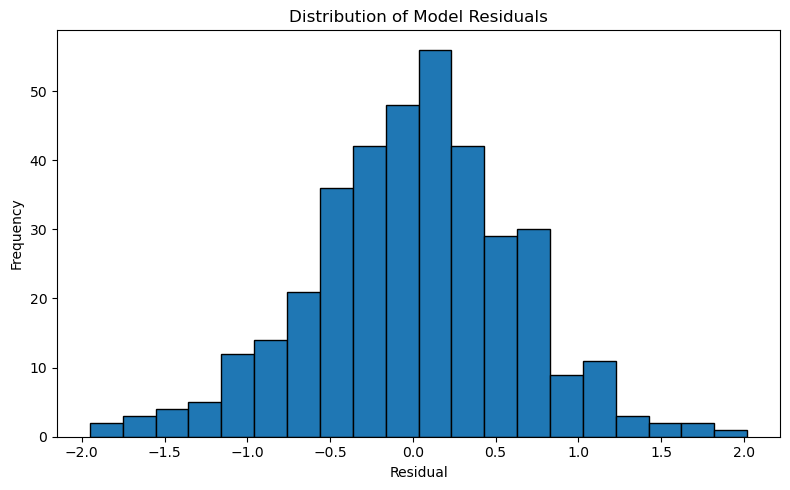

In [99]:
plt.figure(figsize=(8, 5))

plt.hist(
    diagnostic_df["Residual"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Model Residuals")

plt.tight_layout()
plt.show()

### Q-Q Plot

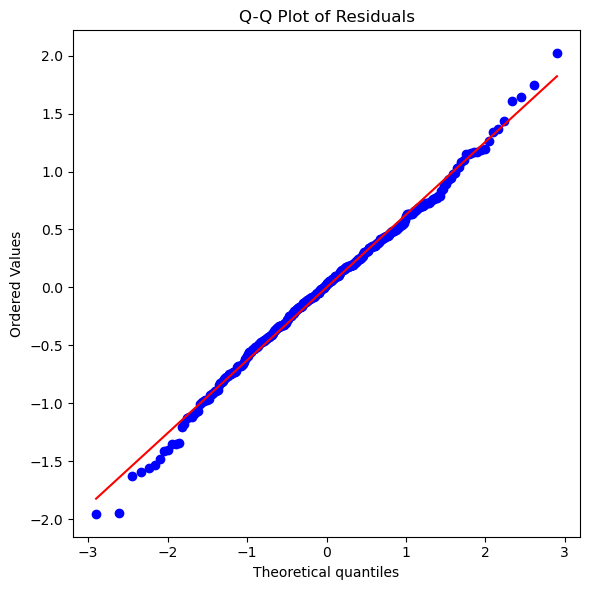

In [100]:
plt.figure(figsize=(6, 6))

stats.probplot(
    diagnostic_df["Residual"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### Standardized Residuals

In [101]:
residual_std = (
    diagnostic_df["Residual"]
    / diagnostic_df["Residual"].std(ddof=1)
)

diagnostic_df[
    "Standardized_Residual"
] = residual_std

In [102]:
display(
    diagnostic_df[
        "Standardized_Residual"
    ]
    .describe()
    .to_frame()
    .round(3)
)

,Standardized_Residual
count,372.000
mean,-0.000
std,1.000
min,-3.115
25%,-0.623
50%,0.037
75%,0.647
max,3.223


### Check potential outliers

In [103]:
outliers = diagnostic_df[
    diagnostic_df[
        "Standardized_Residual"
    ].abs() > 3
].copy()

print(
    "Number of observations with |standardized residual| > 3:",
    len(outliers)
)

display(
    outliers[
        [
            "participant_id",
            "Video_ID",
            "overall_rating",
            "Fitted",
            "Residual",
            "Standardized_Residual"
        ]
    ].sort_values(
        "Standardized_Residual",
        key=abs,
        ascending=False
    )
)

Number of observations with |standardized residual| > 3: 3


,participant_id,Video_ID,overall_rating,Fitted,Residual,Standardized_Residual
229,P-20260713T104611Z-B42563,V08,3,0.980673,2.019327,3.223003
65,P-20260709T052634Z-F27519,V20,2,3.951380,-1.951380,-3.114554
211,P-20260714T140647Z-77077A,V19,1,2.944664,-1.944664,-3.103836


### Plot standardized residuals

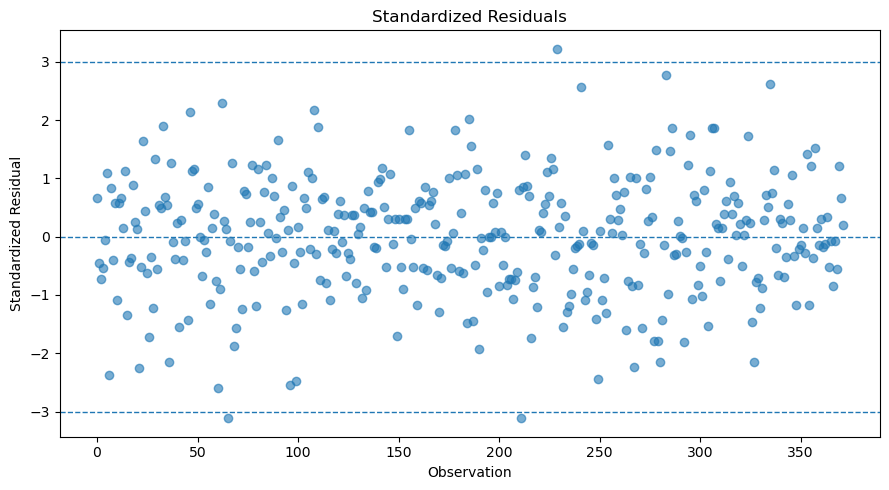

In [104]:
plt.figure(figsize=(9, 5))

plt.scatter(
    range(len(diagnostic_df)),
    diagnostic_df[
        "Standardized_Residual"
    ],
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    y=3,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    y=-3,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observation")
plt.ylabel("Standardized Residual")
plt.title("Standardized Residuals")

plt.tight_layout()
plt.show()

### Simple heteroscedasticity check

In [105]:
resid_fitted_corr, resid_fitted_p = stats.pearsonr(
    diagnostic_df["Fitted"],
    np.abs(
        diagnostic_df["Residual"]
    )
)

print(
    "Correlation between fitted values and absolute residuals:"
)

print(
    "r =",
    round(resid_fitted_corr, 3)
)

print(
    "p =",
    resid_fitted_p
)

Correlation between fitted values and absolute residuals:
r = -0.185
p = 0.000325895008654561


### Model 2 quick diagnostic check

In [106]:
model2_diagnostic_df = model2_data.copy()

model2_diagnostic_df["Fitted"] = (
    model2_result.fittedvalues
)

model2_diagnostic_df["Residual"] = (
    model2_result.resid
)

model2_diagnostic_df[
    "Standardized_Residual"
] = (
    model2_diagnostic_df["Residual"]
    / model2_diagnostic_df[
        "Residual"
    ].std(ddof=1)
)

print(
    "Model 2 observations with |standardized residual| > 3:"
)

print(
    (
        model2_diagnostic_df[
            "Standardized_Residual"
        ].abs() > 3
    ).sum()
)

Model 2 observations with |standardized residual| > 3:
3


### Final mixed-model result table

In [107]:
model1_ci = (
    kansei_result_final.conf_int()
)

model2_ci = (
    model2_result.conf_int()
)

final_results_table = pd.DataFrame({
    "Predictor": [
        "General Kansei Evaluation",
        "Video Set B vs A",
        "Topic Preference Rank 2 vs 1",
        "Topic Preference Rank 3 vs 1"
    ],

    "Model 1 Estimate": [
        kansei_result_final.params[
            "General_Kansei_Evaluation"
        ],
        np.nan,
        np.nan,
        np.nan
    ],

    "Model 1 SE": [
        kansei_result_final.bse[
            "General_Kansei_Evaluation"
        ],
        np.nan,
        np.nan,
        np.nan
    ],

    "Model 2 Estimate": [
        model2_result.params[
            "General_Kansei_Evaluation"
        ],
        model2_result.params[
            "C(Video_Set, Treatment(reference='A'))[T.B]"
        ],
        model2_result.params[
            "C(Topic_Preference_Rank, Treatment(reference=1))[T.2]"
        ],
        model2_result.params[
            "C(Topic_Preference_Rank, Treatment(reference=1))[T.3]"
        ]
    ],

    "Model 2 SE": [
        model2_result.bse[
            "General_Kansei_Evaluation"
        ],
        model2_result.bse[
            "C(Video_Set, Treatment(reference='A'))[T.B]"
        ],
        model2_result.bse[
            "C(Topic_Preference_Rank, Treatment(reference=1))[T.2]"
        ],
        model2_result.bse[
            "C(Topic_Preference_Rank, Treatment(reference=1))[T.3]"
        ]
    ],

    "Model 2 p-value": [
        model2_result.pvalues[
            "General_Kansei_Evaluation"
        ],
        model2_result.pvalues[
            "C(Video_Set, Treatment(reference='A'))[T.B]"
        ],
        model2_result.pvalues[
            "C(Topic_Preference_Rank, Treatment(reference=1))[T.2]"
        ],
        model2_result.pvalues[
            "C(Topic_Preference_Rank, Treatment(reference=1))[T.3]"
        ]
    ]
})

display(
    final_results_table.round(4)
)

,Predictor,Model 1 Estimate,Model 1 SE,Model 2 Estimate,Model 2 SE,Model 2 p-value
0,General Kansei Evaluation,1.033,0.0383,1.0386,0.0386,0.0000
1,Video Set B vs A,NaN,NaN,-0.1014,0.1002,0.3114
2,Topic Preference Rank 2 vs 1,NaN,NaN,-0.0174,0.0815,0.8307
3,Topic Preference Rank 3 vs 1,NaN,NaN,0.0292,0.0814,0.7199


### Final model fit table

In [108]:
final_fit_table = pd.DataFrame({
    "Model": [
        "Null Model",
        "Model 1: General Kansei",
        "Model 2: Adjusted"
    ],

    "Log-Likelihood": [
        null_result.llf,
        kansei_result_final.llf,
        model2_result.llf
    ],

    "AIC": [
        null_result.aic,
        kansei_result_final.aic,
        model2_result.aic
    ],

    "BIC": [
        null_result.bic,
        kansei_result_final.bic,
        model2_result.bic
    ]
})

display(
    final_fit_table.round(3)
)

,Model,Log-Likelihood,AIC,BIC
0,Null Model,-570.642,1149.283,1164.959
1,Model 1: General Kansei,-374.843,759.687,779.281
2,Model 2: Adjusted,-374.166,764.331,795.682


## 8. Sensitivity Analysis: Removing Highly Correlated Kansei Items

In [109]:
# Removing highly correlated Kansei items

items_to_remove = [
    "clear_confusing",
    "coherent_scattered"
]

reduced_kansei_columns = [
    col for col in kansei_columns
    if col not in items_to_remove
]

print("Original number of items:", len(kansei_columns))
print("Reduced number of items:", len(reduced_kansei_columns))

print("\nRemoved items:")
for col in items_to_remove:
    print("-", kansei_labels[col])

print("\nRetained items:")
for col in reduced_kansei_columns:
    print("-", kansei_labels[col])

Original number of items: 15
Reduced number of items: 13

Removed items:
- Clear–Confusing
- Coherent–Scattered

Retained items:
- Attractive–Plain
- Organized–Disorganized
- Comfortable–Uncomfortable
- Professional–Amateur
- Understandable–Confusing
- Interesting–Boring
- Factual–Misleading
- Convincing–Doubtful
- Pleasant–Unpleasant
- Clear–Unclear
- Smooth–Abrupt
- Friendly–Unfriendly
- Motivating–Demotivating


In [110]:
high_corr_pairs = [
    ("coherent_scattered", "organized_disorganized"),
    ("clear_confusing", "organized_disorganized"),
    ("clear_confusing", "understandable_confusing")
]

high_corr_results = []

for item1, item2 in high_corr_pairs:

    r, p = stats.pearsonr(
        analysis_df[item1],
        analysis_df[item2]
    )

    high_corr_results.append({
        "Item 1": kansei_labels[item1],
        "Item 2": kansei_labels[item2],
        "Pearson r": r,
        "p-value": p
    })

high_corr_results = pd.DataFrame(
    high_corr_results
)

display(
    high_corr_results.round(3)
)

,Item 1,Item 2,Pearson r,p-value
0,Coherent–Scattered,Organized–Disorganized,0.832,0.0
1,Clear–Confusing,Organized–Disorganized,0.805,0.0
2,Clear–Confusing,Understandable–Confusing,0.792,0.0


### Reliability of the reduced 13-item scale

In [111]:
reduced_alpha = cronbach_alpha(
    analysis_df[reduced_kansei_columns]
)

print(
    "Cronbach's alpha for reduced 13-item scale:",
    round(reduced_alpha, 3)
)

Cronbach's alpha for reduced 13-item scale: 0.963


In [112]:
reduced_omega = mcdonald_omega(
    analysis_df[reduced_kansei_columns]
)

print(
    "McDonald's omega for reduced 13-item scale:",
    round(reduced_omega, 3)
)

McDonald's omega for reduced 13-item scale: 0.964


In [113]:
reliability_sensitivity_table = pd.DataFrame({
    "Scale": [
        "Original 15-item",
        "Reduced 13-item"
    ],
    "Number of Items": [
        15,
        13
    ],
    "Cronbach Alpha": [
        overall_alpha,
        reduced_alpha
    ],
    "McDonald's Omega": [
        overall_omega,
        reduced_omega
    ]
})

display(
    reliability_sensitivity_table.round(3)
)

,Scale,Number of Items,Cronbach Alpha,McDonald's Omega
0,Original 15-item,15,0.968,0.969
1,Reduced 13-item,13,0.963,0.964


### Reliability by original conceptual dimensions

In [114]:
reduced_dimensions = {
    "Visual": [
        "attractive_plain",
        "organized_disorganized",
        "comfortable_uncomfortable"
    ],

    "Content": [
        "professional_amateur",
        "understandable_confusing",
        "interesting_boring",
        "factual_misleading",
        "convincing_doubtful"
    ],

    "Audio_Narrator": [
        "pleasant_unpleasant",
        "clear_unclear",
        "smooth_abrupt",
        "friendly_unfriendly",
        "motivating_demotivating"
    ]
}

In [115]:
reduced_dimension_reliability = []

for dimension, columns in reduced_dimensions.items():

    alpha = cronbach_alpha(
        analysis_df[columns]
    )

    omega = mcdonald_omega(
        analysis_df[columns]
    )

    reduced_dimension_reliability.append({
        "Dimension": dimension,
        "Number of Items": len(columns),
        "Cronbach Alpha": alpha,
        "McDonald's Omega": omega
    })

reduced_dimension_reliability = pd.DataFrame(
    reduced_dimension_reliability
)

display(
    reduced_dimension_reliability.round(3)
)

,Dimension,Number of Items,Cronbach Alpha,McDonald's Omega
0,Visual,3,0.875,0.879
1,Content,5,0.904,0.913
2,Audio_Narrator,5,0.940,0.941


### KMO and Bartlett’s test for the reduced scale

In [116]:
reduced_efa_data = (
    analysis_df[
        reduced_kansei_columns
    ]
    .dropna()
    .copy()
)

print(
    "Reduced EFA sample size:",
    len(reduced_efa_data)
)

print(
    "Number of items:",
    reduced_efa_data.shape[1]
)

Reduced EFA sample size: 372
Number of items: 13


In [117]:
reduced_kmo_per_item, reduced_kmo_total = (
    calculate_kmo(
        reduced_efa_data
    )
)

print(
    "Overall KMO for reduced scale:",
    round(reduced_kmo_total, 3)
)

Overall KMO for reduced scale: 0.952


In [118]:
reduced_bartlett_chi2, reduced_bartlett_p = (
    calculate_bartlett_sphericity(
        reduced_efa_data
    )
)

print(
    "Bartlett's chi-square:",
    round(reduced_bartlett_chi2, 3)
)

print(
    "Bartlett's p-value:",
    reduced_bartlett_p
)

Bartlett's chi-square: 4939.355
Bartlett's p-value: 0.0


### Parallel Analysis again
移除兩個 highly correlated adjectives 後，還是不是只有一個 factor？

In [119]:
(
    reduced_real_eigenvalues,
    reduced_random_eigenvalues_95
) = parallel_analysis(
    reduced_efa_data,
    n_iterations=1000
)

In [120]:
reduced_parallel_table = pd.DataFrame({
    "Factor": np.arange(
        1,
        len(reduced_real_eigenvalues) + 1
    ),
    "Real Eigenvalue":
        reduced_real_eigenvalues,
    "Random 95th Percentile":
        reduced_random_eigenvalues_95
})

reduced_parallel_table[
    "Retain"
] = (
    reduced_parallel_table[
        "Real Eigenvalue"
    ]
    >
    reduced_parallel_table[
        "Random 95th Percentile"
    ]
)

display(
    reduced_parallel_table.round(3)
)

,Factor,Real Eigenvalue,Random 95th Percentile,Retain
0,1,9.057,1.396,True
1,2,0.934,1.296,False
2,3,0.715,1.225,False
3,4,0.377,1.164,False
4,5,0.314,1.115,False
5,6,0.291,1.067,False
6,7,0.252,1.024,False
7,8,0.224,0.980,False
8,9,0.212,0.939,False
9,10,0.200,0.898,False


In [121]:
reduced_n_factors = int(
    (
        reduced_real_eigenvalues
        >
        reduced_random_eigenvalues_95
    ).sum()
)

print(
    "Number of factors suggested by parallel analysis:",
    reduced_n_factors
)

Number of factors suggested by parallel analysis: 1


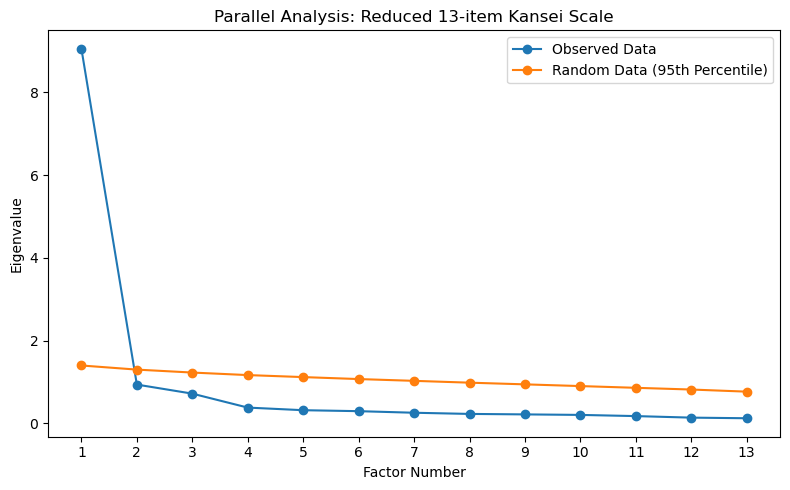

In [122]:
plt.figure(figsize=(8, 5))

factor_numbers = np.arange(
    1,
    len(reduced_real_eigenvalues) + 1
)

plt.plot(
    factor_numbers,
    reduced_real_eigenvalues,
    marker="o",
    label="Observed Data"
)

plt.plot(
    factor_numbers,
    reduced_random_eigenvalues_95,
    marker="o",
    label="Random Data (95th Percentile)"
)

plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")

plt.title(
    "Parallel Analysis: Reduced 13-item Kansei Scale"
)

plt.xticks(factor_numbers)

plt.legend()
plt.tight_layout()
plt.show()

### EFA using the reduced 13-item scale

In [123]:
reduced_efa_model = FactorAnalyzer(
    n_factors=reduced_n_factors,
    rotation=None if reduced_n_factors == 1 else "oblimin",
    method="minres"
)

reduced_efa_model.fit(
    reduced_efa_data
)

FactorAnalyzer(n_factors=1, rotation=None, rotation_kwargs={})

In [124]:
reduced_factor_names = [
    f"Factor_{i+1}"
    for i in range(reduced_n_factors)
]

reduced_loading_table = pd.DataFrame(
    reduced_efa_model.loadings_,
    index=[
        kansei_labels[col]
        for col in reduced_kansei_columns
    ],
    columns=reduced_factor_names
)

display(
    reduced_loading_table.round(3)
)

,Factor_1
Attractive–Plain,0.758
Organized–Disorganized,0.870
Comfortable–Uncomfortable,0.869
Professional–Amateur,0.797
Understandable–Confusing,0.803
Interesting–Boring,0.752
Factual–Misleading,0.758
Convincing–Doubtful,0.809
Pleasant–Unpleasant,0.844
Clear–Unclear,0.822


### Variance explained

In [125]:
reduced_variance = (
    reduced_efa_model.get_factor_variance()
)

reduced_variance_table = pd.DataFrame({
    "Factor": reduced_factor_names,
    "SS Loadings": reduced_variance[0],
    "Proportion Variance":
        reduced_variance[1],
    "Cumulative Variance":
        reduced_variance[2]
})

display(
    reduced_variance_table.round(3)
)

,Factor,SS Loadings,Proportion Variance,Cumulative Variance
0,Factor_1,8.735,0.672,0.672


### Create reduced factor scores

In [126]:
reduced_factor_scores = (
    reduced_efa_model.transform(
        reduced_efa_data
    )
)

In [127]:
reduced_factor_score_df = pd.DataFrame(
    reduced_factor_scores,
    columns=[
        "General_Kansei_Evaluation_13"
    ],
    index=reduced_efa_data.index
)

display(
    reduced_factor_score_df.head()
)

,General_Kansei_Evaluation_13
0,1.358699
1,1.020401
2,1.220539
3,0.179905
4,0.735279


In [128]:
analysis_df[
    "General_Kansei_Evaluation_13"
] = reduced_factor_score_df[
    "General_Kansei_Evaluation_13"
]

display(
    analysis_df[
        [
            "General_Kansei_Evaluation",
            "General_Kansei_Evaluation_13"
        ]
    ].describe().round(3)
)

,General_Kansei_Evaluation,General_Kansei_Evaluation_13
count,372.000,372.000
mean,0.000,-0.000
std,0.987,0.984
min,-2.886,-2.865
25%,-0.643,-0.633
50%,0.118,0.110
75%,0.721,0.738
max,1.412,1.433


### Compare original and reduced factor scores

In [130]:
factor_score_corr, factor_score_p = (
    stats.pearsonr(
        analysis_df[
            "General_Kansei_Evaluation"
        ],
        analysis_df[
            "General_Kansei_Evaluation_13"
        ]
    )
)

print(
    "Correlation between 15-item and 13-item factor scores:"
)

print(
    "r =",
    round(factor_score_corr, 3)
)

print(
    "p =",
    factor_score_p
)

Correlation between 15-item and 13-item factor scores:
r = 0.997
p = 0.0
